In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats

In [3]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [5]:
from sklearn.preprocessing import PowerTransformer

In [7]:
df=pd.read_csv('concrete_data.csv')

In [9]:
df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [11]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [13]:
df.shape

(1030, 9)

In [15]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [17]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [19]:
x=df.drop(columns=['Strength'])
y=df.iloc[:-1]

In [27]:
x = x.loc[y.index]  # or y = y.loc[x.index]

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [31]:
#apply Regression without any transformation
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
r2_score(y_test,y_pred)

0.946738557768825

In [35]:
# cross validation with cross val score
lr=LinearRegression()
np.mean(cross_val_score(lr,x,y,scoring='r2'))

0.8956655769721596

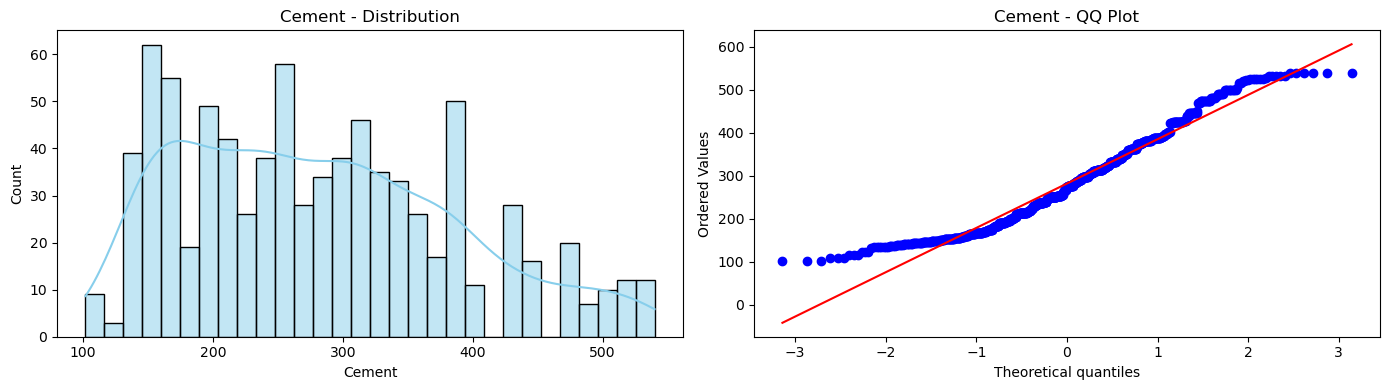

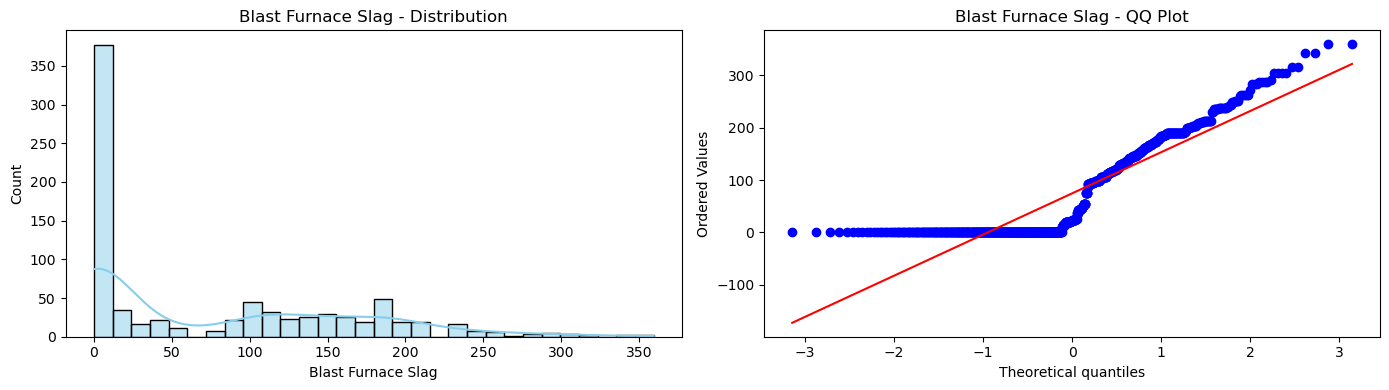

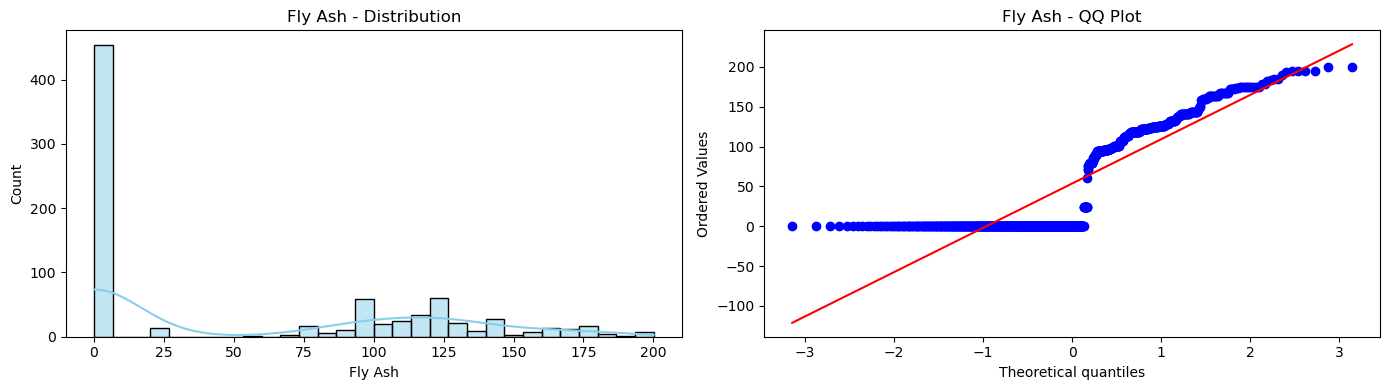

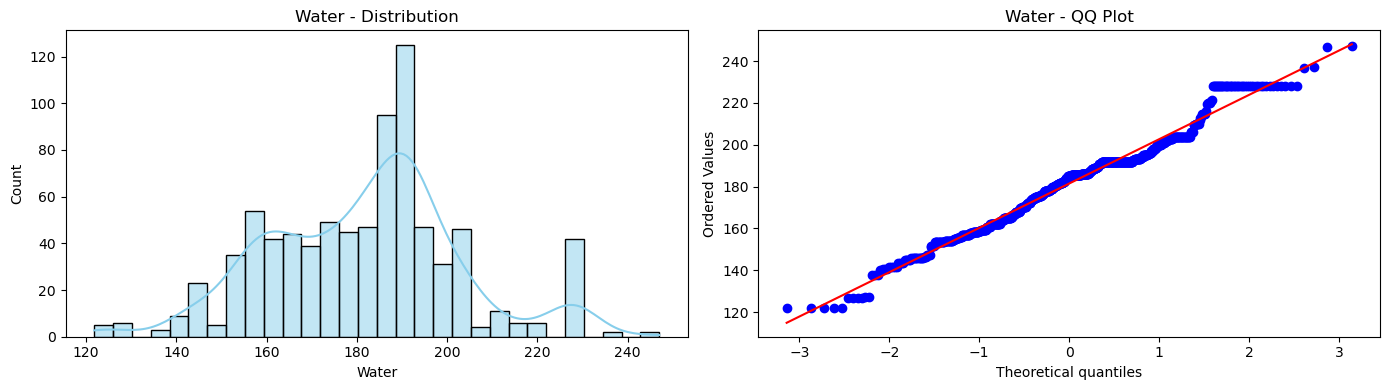

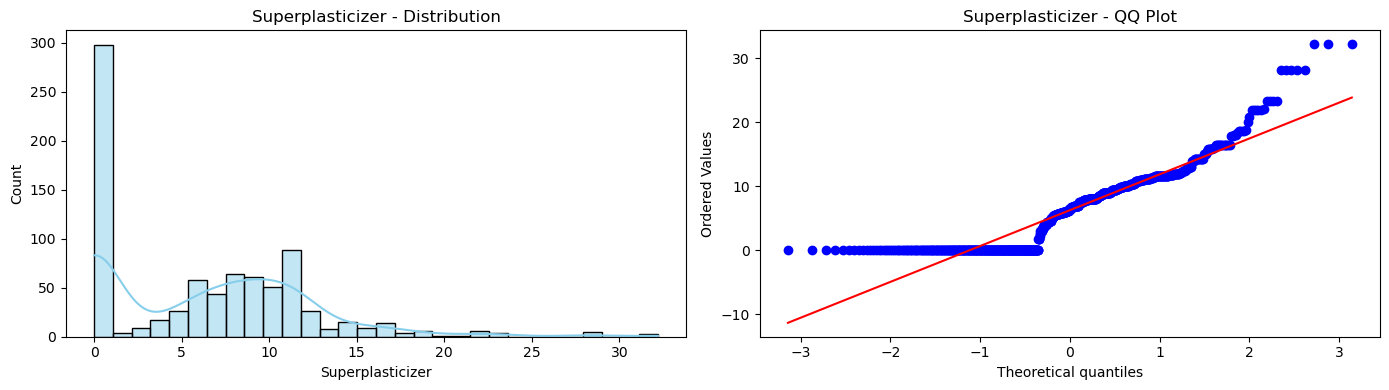

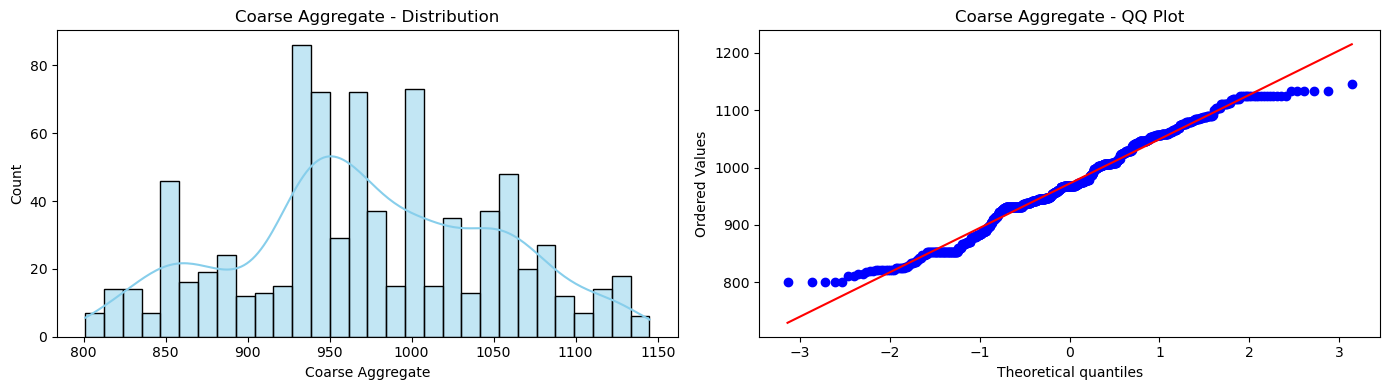

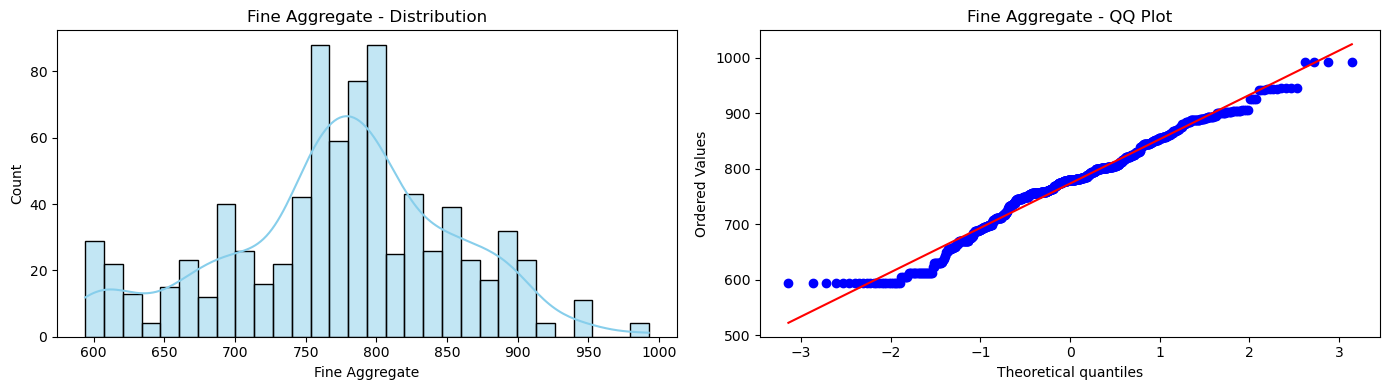

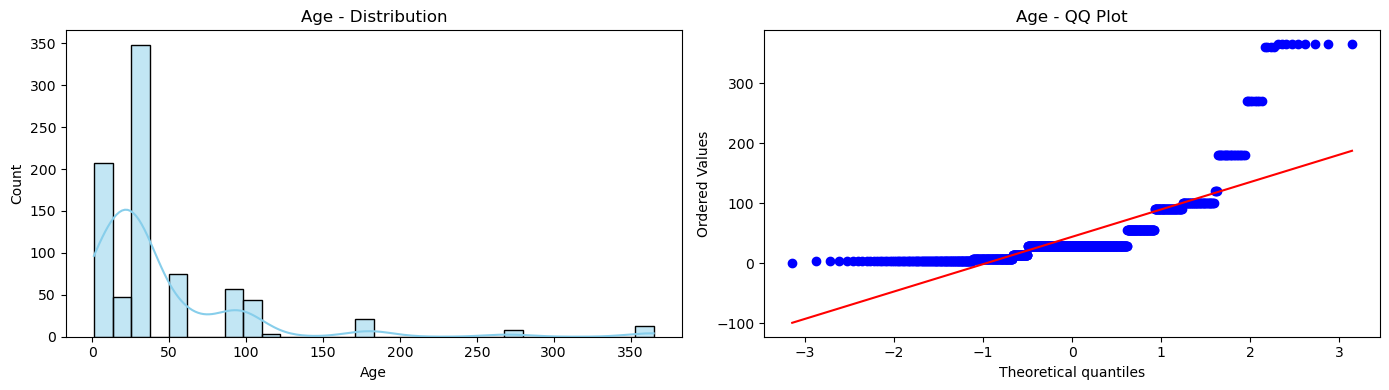

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

for col in x_train.columns:
    plt.figure(figsize=(14, 4))

    # Histogram + KDE plot (replaces distplot)
    plt.subplot(1, 2, 1)
    sns.histplot(x_train[col], kde=True, bins=30, color='skyblue')
    plt.title(f'{col} - Distribution')

    # QQ plot
    plt.subplot(1, 2, 2)
    stats.probplot(x_train[col], dist="norm", plot=plt)
    plt.title(f'{col} - QQ Plot')

    plt.tight_layout()
    plt.show()


In [51]:

# Using cross val score

pt = PowerTransformer(method='box-cox')
x_transformed = pt.fit_transform(x+0.0000001)

lr = LinearRegression()
np.mean(cross_val_score(lr,x_transformed,y,scoring='r2'))

-3.115484661803241

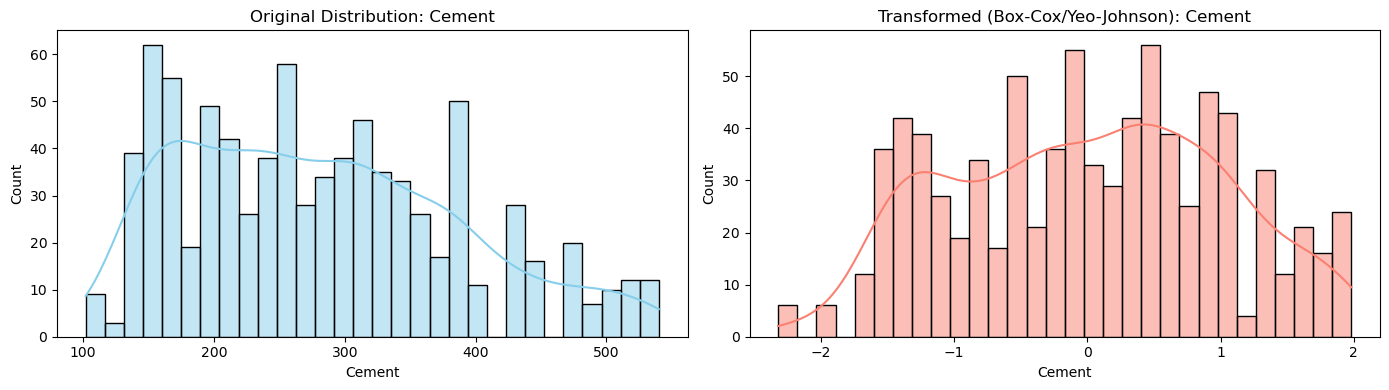

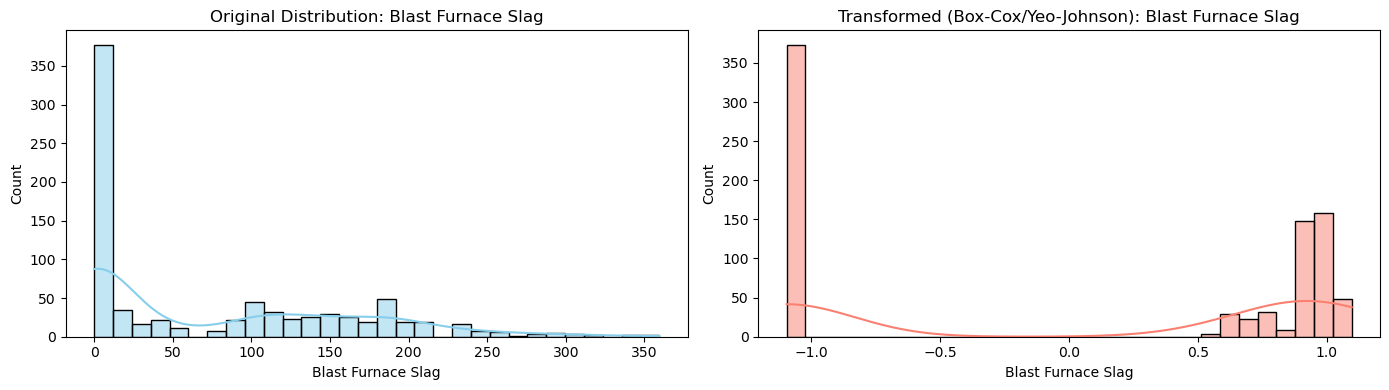

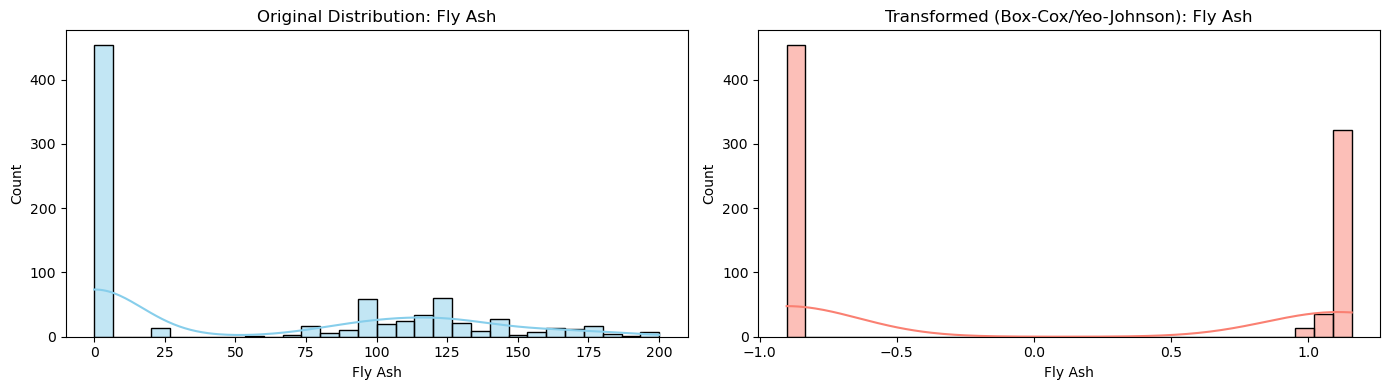

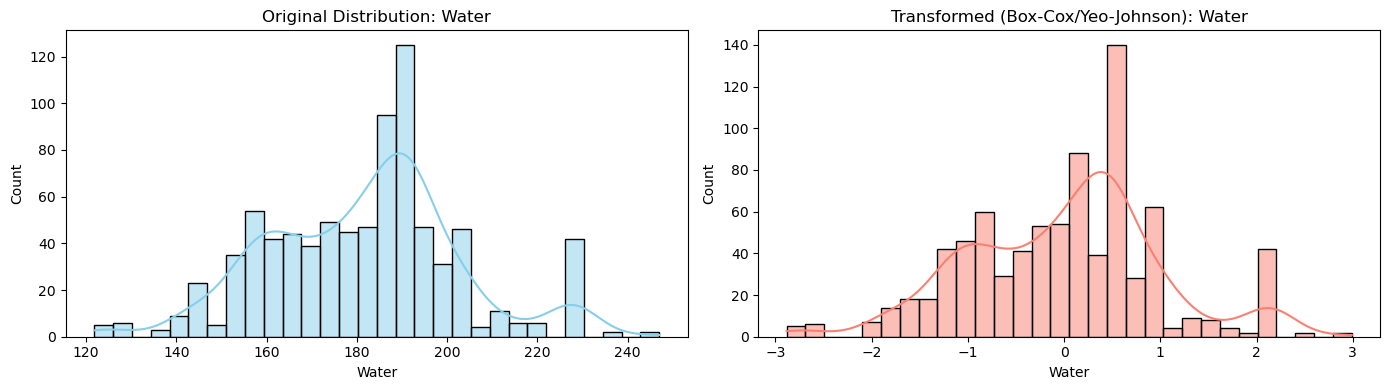

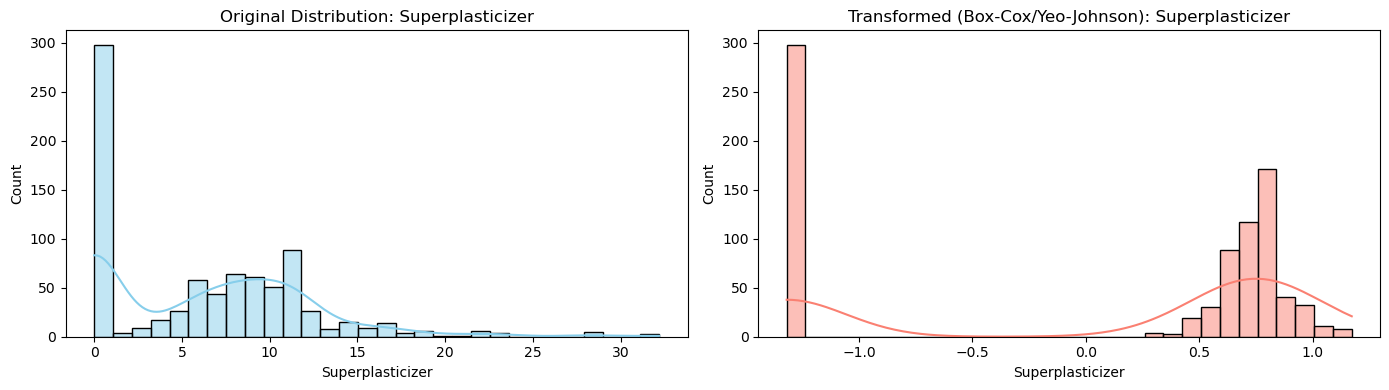

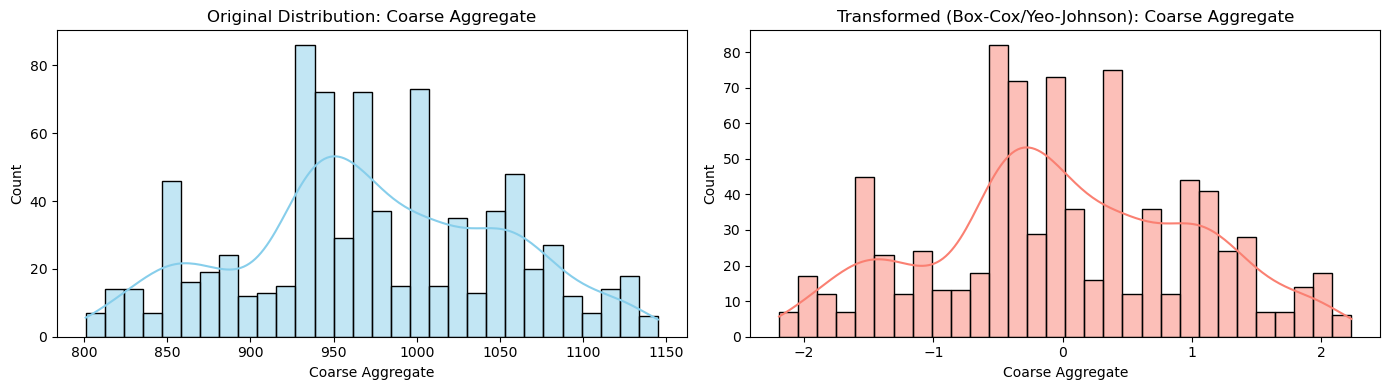

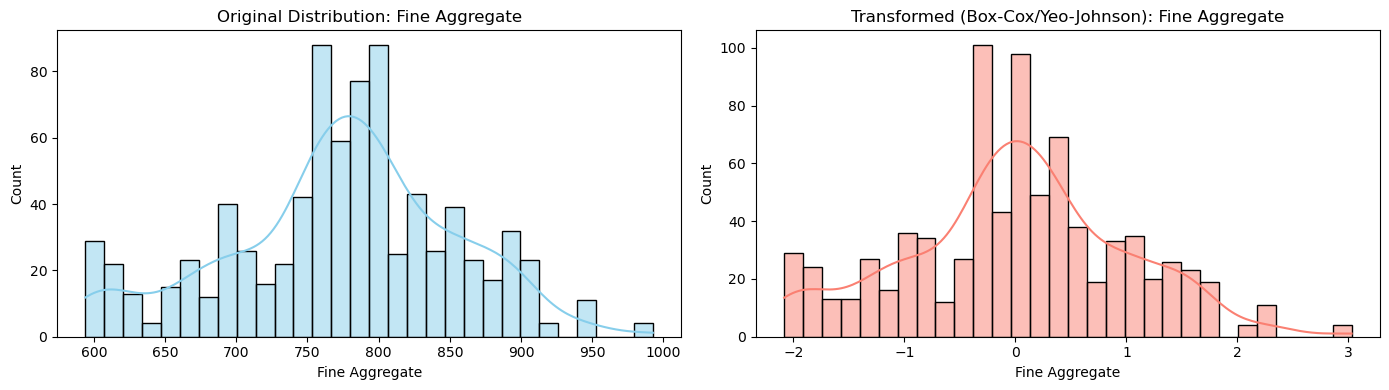

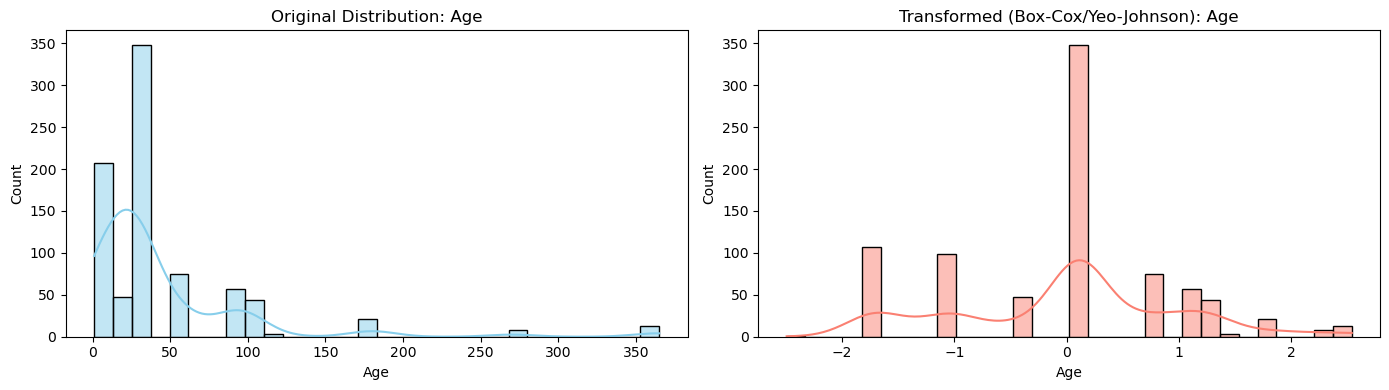

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Transformed DataFrame (you already created this)
X_train_transformed = pd.DataFrame(x_train_transformed, columns=x_train.columns)

# Plot before and after transformation for each feature
for col in X_train_transformed.columns:
    plt.figure(figsize=(14, 4))
    
    # Original
    plt.subplot(1, 2, 1)
    sns.histplot(x_train[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Original Distribution: {col}')
    
    # Transformed
    plt.subplot(1, 2, 2)
    sns.histplot(X_train_transformed[col], kde=True, bins=30, color='salmon')
    plt.title(f'Transformed (Box-Cox/Yeo-Johnson): {col}')
    
    plt.tight_layout()
    plt.show()


In [61]:
# Apply Yeo-Johnson transform

pt1 = PowerTransformer()

X_train_transformed2 = pt1.fit_transform(x_train)
X_test_transformed2 = pt1.transform(x_test)

lr = LinearRegression()
lr.fit(X_train_transformed2,y_train)

y_pred3 = lr.predict(X_test_transformed2)

print(r2_score(y_test,y_pred3))

pd.DataFrame({'cols':x_train.columns,'Yeo_Johnson_lambdas':pt1.lambdas_})

0.9132037966737752


,cols,Yeo_Johnson_lambdas
0,Cement,0.171057
1,Blast Furnace Slag,0.023312
2,Fly Ash,-0.142249
3,Water,0.814179
4,Superplasticizer,0.278638
5,Coarse Aggregate,1.055930
6,Fine Aggregate,1.827849
7,Age,0.018517


In [63]:
# applying cross val score

pt = PowerTransformer()
X_transformed2 = pt.fit_transform(x)

lr = LinearRegression()
np.mean(cross_val_score(lr,X_transformed2,y,scoring='r2'))

-4.082715814975365

In [67]:
X_train_transformed2 = pd.DataFrame(X_train_transformed2,columns=x_train.columns)

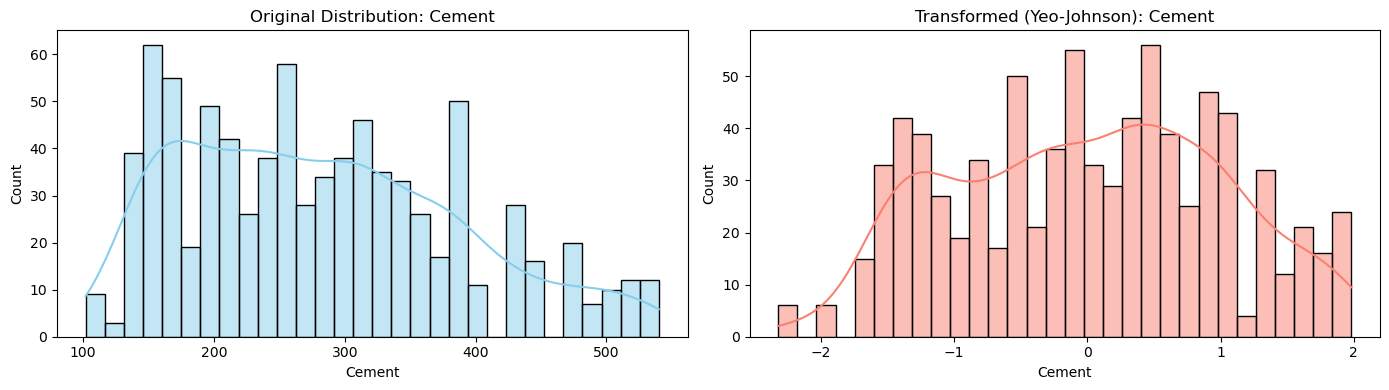

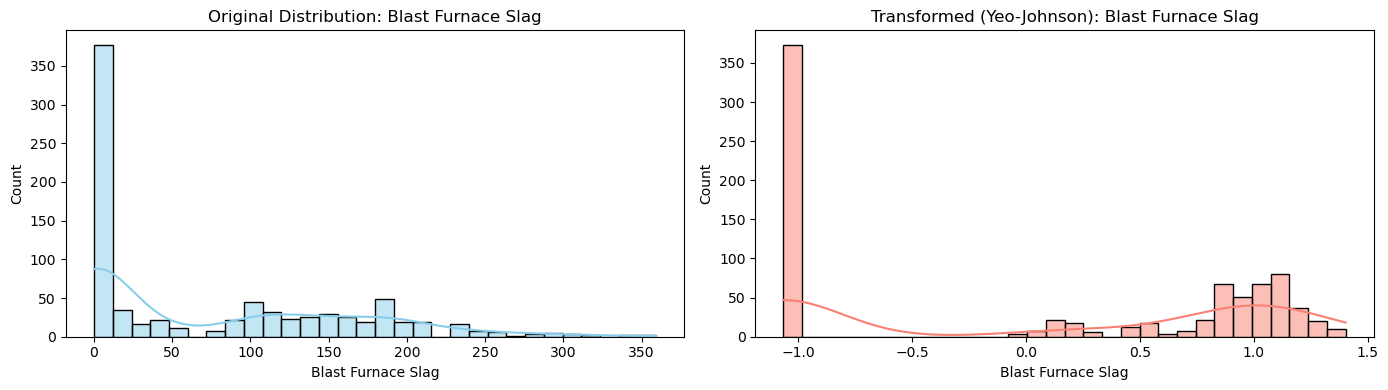

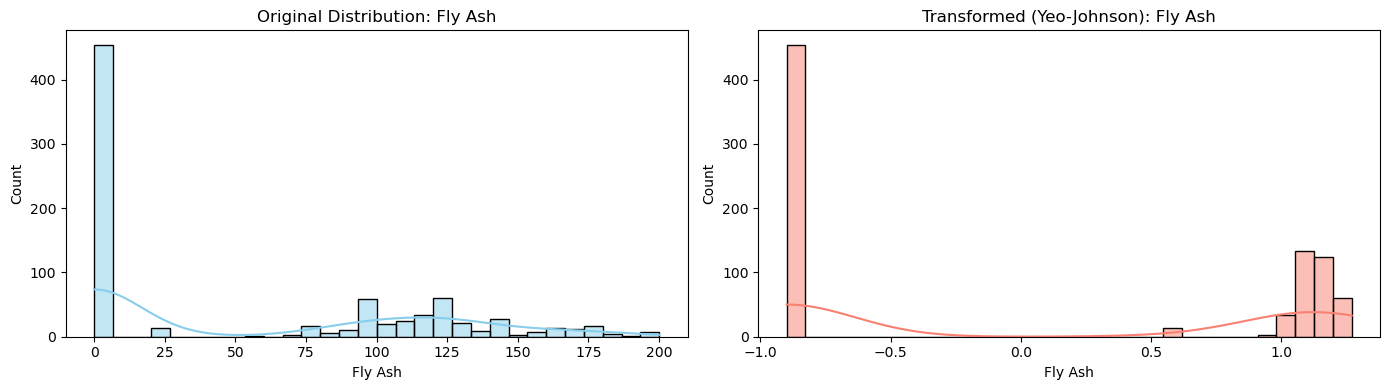

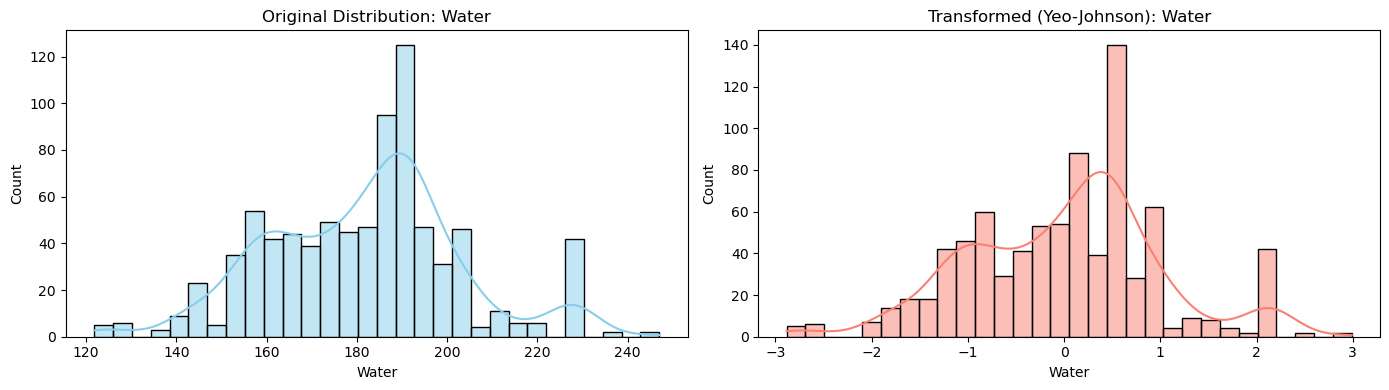

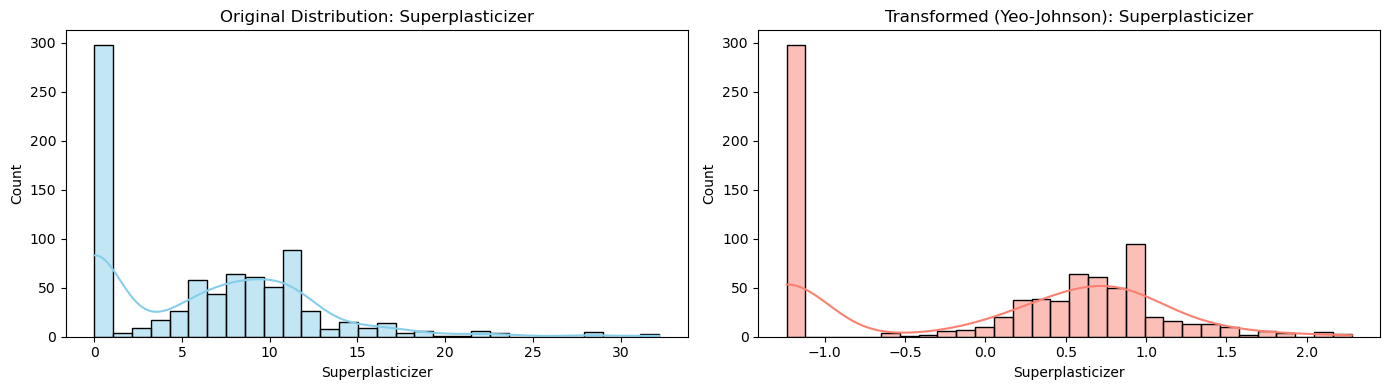

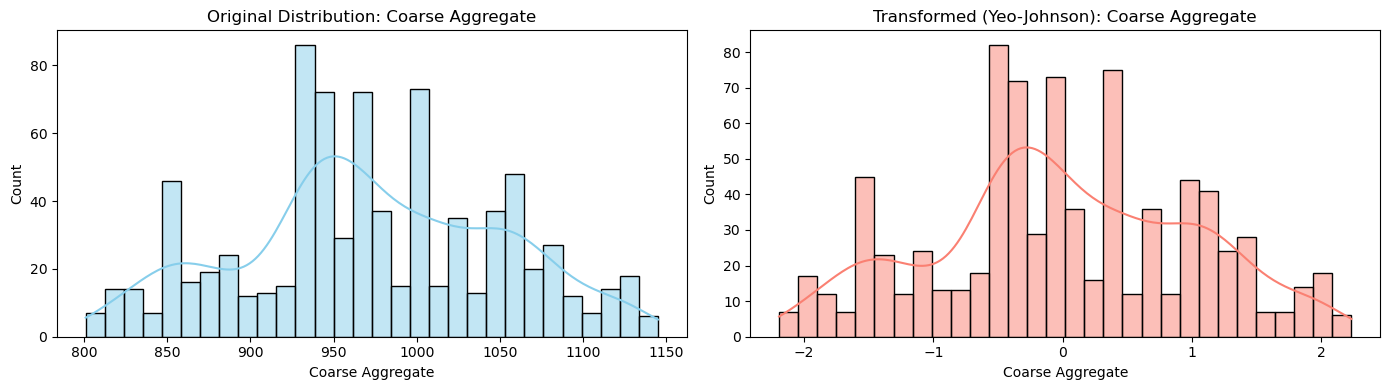

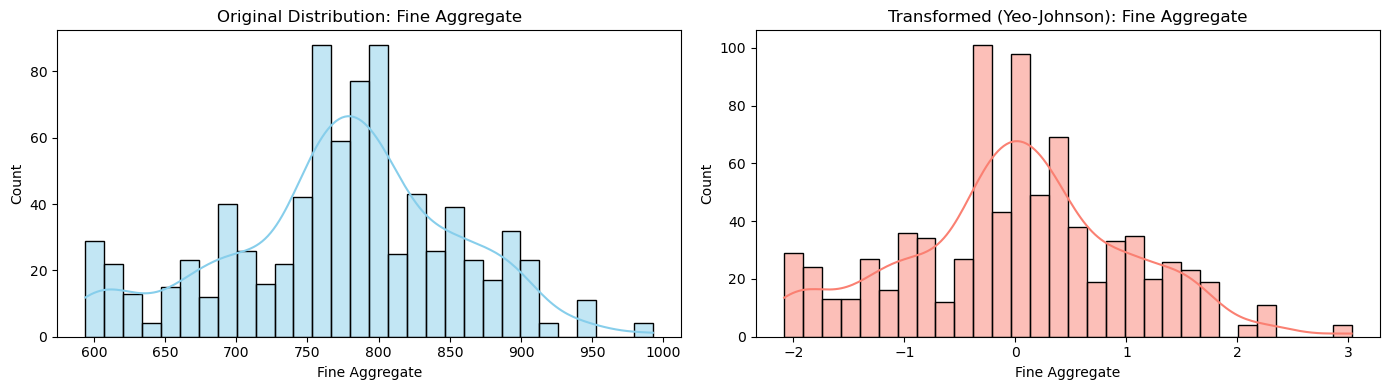

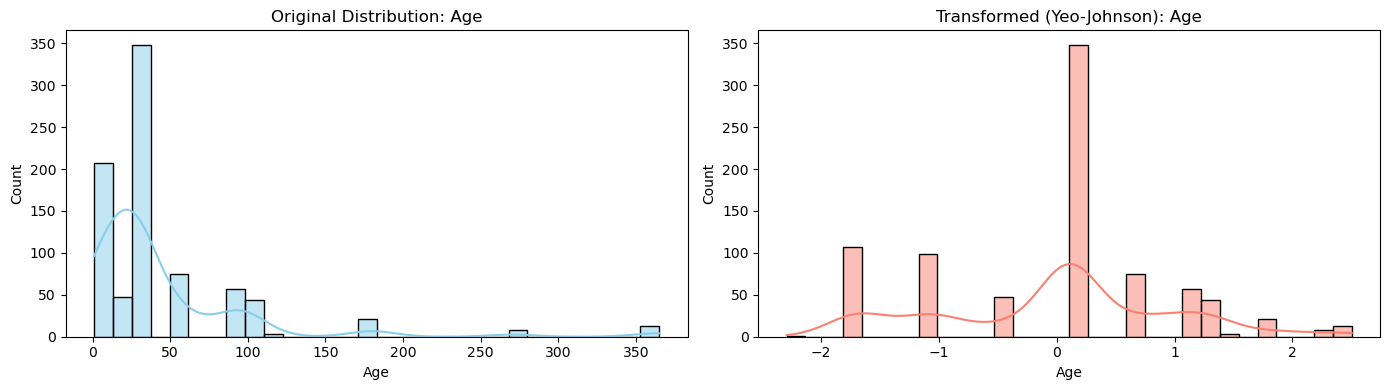

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Replace distplot with histplot (with kde=True)
for col in X_train_transformed2.columns:
    plt.figure(figsize=(14, 4))
    
    # Original distribution
    plt.subplot(1, 2, 1)
    sns.histplot(x_train[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Original Distribution: {col}')
    
    # Transformed distribution
    plt.subplot(1, 2, 2)
    sns.histplot(X_train_transformed2[col], kde=True, bins=30, color='salmon')
    plt.title(f'Transformed (Yeo-Johnson): {col}')
    
    plt.tight_layout()
    plt.show()
